#  NLP Skill Extraction - Sri Lankan IT/Tech Job Market
### Extracting in-demand skills from ikman.lk job descriptions
**Method:** Dictionary-based keyword matching + frequency analysis  
**Input:** `data/ikman_jobs_clean.csv` (216 listings, 5 categories)


## 1. Setup & Data Loading

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5),
                     "axes.titlesize": 14, "axes.labelsize": 12})

df = pd.read_csv("data/ikman_jobs_clean.csv")
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Categories: {df['category'].value_counts().to_dict()}")
df.head(3)

Loaded: 216 rows x 10 columns
Categories: {'IT and Network Industry': 79, 'Digital Marketing': 68, 'Engineering': 45, 'Analyst': 14, 'Designer': 10}


,category,title,company,location,salary_min,salary_max,salary_mid,days_ago,detail_url,description
0,IT and Network Industry,Quality Assurance (QA) Engineer,Lakmini International (Pvt) Ltd,Colombo,NaN,NaN,NaN,NaN,https://ikman.lk/en/ad/quality-assurance-qa-en...,Quality Assurance (QA) Engineer Software Testi...
1,IT and Network Industry,Hardware Support Engineer,INFOTECH COMPUTERS PRIVATE LIMITED,Colombo,30000.0,50000.0,40000.0,0.62,https://ikman.lk/en/ad/hardware-support-engine...,A growing IT company based in Colombo is looki...
2,IT and Network Industry,Computer Technician,Miracala Computers,Colombo,NaN,NaN,NaN,0.71,https://ikman.lk/en/ad/computer-technician-col...,WANTED Computer Technician\nJob Duties Compute...


## 2. Skills Dictionary
A curated dictionary of skills grouped by category type.  
Each skill has a list of patterns (handles abbreviations, common variants).


In [28]:
SKILLS = {
    # ── Programming & Dev ──────────────────────────────────────────
    "Python":         [r"\bpython\b"],
    "JavaScript":     [r"\bjavascript\b", r"\bjs\b"],
    "Java":           [r"\bjava\b(?!script)"],
    "PHP":            [r"\bphp\b"],
    "C#":             [r"\bc#\b", r"\bcsharp\b"],
    "C++":            [r"\bc\+\+\b"],
    "TypeScript":     [r"\btypescript\b", r"\bts\b"],
    "R":              [r"\br programming\b", r"\blanguage r\b"],
    "SQL":            [r"\bsql\b"],
    "HTML":           [r"\bhtml\b"],
    "CSS":            [r"\bcss\b"],

    # ── Frameworks & Libraries ─────────────────────────────────────
    "React":          [r"\breact\b", r"\breactjs\b", r"\breact\.js\b"],
    "Angular":        [r"\bangular\b"],
    "Vue":            [r"\bvue\b", r"\bvuejs\b"],
    "Node.js":        [r"\bnode\.?js\b", r"\bnodejs\b"],
    "Laravel":        [r"\blaravel\b"],
    "Django":         [r"\bdjango\b"],
    "Flask":          [r"\bflask\b"],
    "Spring Boot":    [r"\bspring\s?boot\b", r"\bspring\b"],
    "Bootstrap":      [r"\bbootstrap\b"],

    # ── Data & Analytics ──────────────────────────────────────────
    "Excel":          [r"\bexcel\b", r"\bms excel\b", r"\bmicrosoft excel\b"],
    "Power BI":       [r"\bpower\s?bi\b"],
    "Tableau":        [r"\btableau\b"],
    "Google Analytics": [r"\bgoogle analytics\b"],
    "Pandas":         [r"\bpandas\b"],
    "NumPy":          [r"\bnumpy\b"],
    "Machine Learning": [r"\bmachine learning\b", r"\bml\b(?! engineer)"],
    "Deep Learning":  [r"\bdeep learning\b"],
    "TensorFlow":     [r"\btensorflow\b"],
    "NLP":            [r"\bnlp\b", r"\bnatural language processing\b"],

    # ── Cloud & DevOps ─────────────────────────────────────────────
    "AWS":            [r"\baws\b", r"\bamazon web services\b"],
    "Azure":          [r"\bazure\b"],
    "GCP":            [r"\bgcp\b", r"\bgoogle cloud\b"],
    "Docker":         [r"\bdocker\b"],
    "Git":            [r"\bgit\b(?!hub)"],
    "GitHub":         [r"\bgithub\b"],
    "Linux":          [r"\blinux\b", r"\bubuntu\b"],

    # ── Databases ─────────────────────────────────────────────────
    "MySQL":          [r"\bmysql\b"],
    "PostgreSQL":     [r"\bpostgresql\b", r"\bpostgres\b"],
    "MongoDB":        [r"\bmongodb\b", r"\bmongo\b"],
    "Microsoft SQL Server": [r"\bms sql\b", r"\bsql server\b", r"\bmssql\b"],
    "Firebase":       [r"\bfirebase\b"],

    # ── Digital Marketing ─────────────────────────────────────────
    "SEO":            [r"\bseo\b", r"\bsearch engine optimization\b"],
    "SEM":            [r"\bsem\b", r"\bsearch engine marketing\b"],
    "Social Media":   [r"\bsocial media\b"],
    "Content Writing": [r"\bcontent writing\b", r"\bcontent creation\b", r"\bcopywriting\b"],
    "Email Marketing": [r"\bemail marketing\b"],
    "Facebook Ads":   [r"\bfacebook ads\b", r"\bfb ads\b", r"\bmeta ads\b"],
    "Google Ads":     [r"\bgoogle ads\b", r"\badwords\b"],
    "TikTok":         [r"\btiktok\b"],
    "Instagram":      [r"\binstagram\b"],
    "Canva":          [r"\bcanva\b"],

    # ── Design ────────────────────────────────────────────────────
    "Photoshop":      [r"\bphotoshop\b", r"\badobe photoshop\b"],
    "Illustrator":    [r"\billustrator\b", r"\badobe illustrator\b"],
    "Figma":          [r"\bfigma\b"],
    "Adobe XD":       [r"\badobe xd\b"],
    "Premiere Pro":   [r"\bpremiere\b", r"\bpremiere pro\b"],
    "After Effects":  [r"\bafter effects\b"],
    "InDesign":       [r"\bindesign\b"],
    "UI/UX":          [r"\bui[/ ]?ux\b", r"\buser interface\b", r"\buser experience\b"],
    "Video Editing":  [r"\bvideo edit\w*\b"],

    # ── Engineering ───────────────────────────────────────────────
    "AutoCAD":        [r"\bautocad\b"],
    "SolidWorks":     [r"\bsolidworks\b"],
    "MATLAB":         [r"\bmatlab\b"],
    "Project Management": [r"\bproject management\b"],
    "Networking":     [r"\bnetworking\b", r"\bnetwork administration\b"],
    "Cisco":          [r"\bcisco\b"],

    # ── Soft & General ────────────────────────────────────────────
    "Communication":  [r"\bcommunication\b"],
    "Teamwork":       [r"\bteamwork\b", r"\bteam player\b"],
    "Problem Solving": [r"\bproblem.?solv\w*\b"],
    "MS Office":      [r"\bms office\b", r"\bmicrosoft office\b", r"\boffice suite\b"],
}

print(f"Total skills in dictionary: {len(SKILLS)}")
print("\nSkill categories:")
groups = {
    "Programming":    ["Python","JavaScript","Java","PHP","C#","C++","TypeScript","R","SQL","HTML","CSS"],
    "Frameworks":     ["React","Angular","Vue","Node.js","Laravel","Django","Flask","Spring Boot","Bootstrap"],
    "Data/Analytics": ["Excel","Power BI","Tableau","Google Analytics","Pandas","NumPy","Machine Learning","Deep Learning","TensorFlow","NLP"],
    "Cloud/DevOps":   ["AWS","Azure","GCP","Docker","Git","GitHub","Linux"],
    "Databases":      ["MySQL","PostgreSQL","MongoDB","Microsoft SQL Server","Firebase"],
    "Digital Mktg":   ["SEO","SEM","Social Media","Content Writing","Email Marketing","Facebook Ads","Google Ads","TikTok","Instagram","Canva"],
    "Design":         ["Photoshop","Illustrator","Figma","Adobe XD","Premiere Pro","After Effects","InDesign","UI/UX","Video Editing"],
    "Engineering":    ["AutoCAD","SolidWorks","MATLAB","Project Management","Networking","Cisco"],
    "Soft Skills":    ["Communication","Teamwork","Problem Solving","MS Office"],
}
for g, skills in groups.items():
    print(f"  {g}: {len(skills)} skills")

Total skills in dictionary: 71

Skill categories:
  Programming: 11 skills
  Frameworks: 9 skills
  Data/Analytics: 10 skills
  Cloud/DevOps: 7 skills
  Databases: 5 skills
  Digital Mktg: 10 skills
  Design: 9 skills
  Engineering: 6 skills
  Soft Skills: 4 skills


## 3. Skill Extraction

In [ ]:
def extract_skills(text: str) -> list:
    """Return list of matched skill names from a job description."""
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    found = []
    for skill, patterns in SKILLS.items():
        for pattern in patterns:
            if re.search(pattern, text_lower):
                found.append(skill)
                break  
    return found


df["skills"] = df["description"].apply(extract_skills)
df["skill_count"] = df["skills"].apply(len)

print(f"Listings with at least 1 skill detected : {(df['skill_count'] > 0).sum()} / {len(df)}")
print(f"Average skills per listing              : {df['skill_count'].mean():.1f}")
print(f"Max skills in one listing               : {df['skill_count'].max()}")
print(f"\nSample extractions:")
for _, row in df[df["skill_count"] > 3].head(5).iterrows():
    print(f"  [{row['category']}] {row['title'][:45]:<45} -> {row['skills']}")

Listings with at least 1 skill detected : 185 / 216
Average skills per listing              : 2.9
Max skills in one listing               : 10

Sample extractions:
  [IT and Network Industry] Graphic Designer - Malabe                     -> ['Social Media', 'Photoshop', 'Illustrator', 'InDesign', 'UI/UX', 'Video Editing', 'Communication']
  [IT and Network Industry] Graphic Designer                              -> ['Social Media', 'Content Writing', 'Email Marketing', 'Instagram', 'Photoshop', 'Illustrator', 'Premiere Pro', 'After Effects', 'Video Editing', 'Communication']
  [IT and Network Industry] PHP Developer (Remote / Online)               -> ['JavaScript', 'PHP', 'HTML', 'CSS', 'Laravel', 'Bootstrap', 'Git', 'GitHub', 'MySQL']
  [IT and Network Industry] Network Systems Engineer - Malabe             -> ['AWS', 'Azure', 'Linux', 'Networking', 'Communication', 'Teamwork']
  [IT and Network Industry] Web Developer                                 -> ['JavaScript', 'HTML', 'CSS', 'L

## 4. Most In-Demand Skills (Overall)

In [30]:
from itertools import chain

all_skills = list(chain.from_iterable(df["skills"]))
skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(25),
                           columns=["skill", "count"])
top_skills["pct"] = (top_skills["count"] / len(df) * 100).round(1)

print("Top 25 skills across all IT/tech job listings:")
print(top_skills.to_string(index=False))

Top 25 skills across all IT/tech job listings:
             skill  count  pct
     Communication    127 58.8
      Social Media     78 36.1
   Problem Solving     52 24.1
         Instagram     36 16.7
          Teamwork     35 16.2
         Photoshop     35 16.2
   Content Writing     32 14.8
            TikTok     32 14.8
       Illustrator     30 13.9
     Video Editing     25 11.6
             Canva     20  9.3
          InDesign     10  4.6
         MS Office     10  4.6
        Google Ads     10  4.6
               SEO      9  4.2
             Excel      9  4.2
        Networking      8  3.7
            Python      8  3.7
      Facebook Ads      8  3.7
      Premiere Pro      7  3.2
     After Effects      6  2.8
Project Management      6  2.8
              HTML      5  2.3
   Email Marketing      4  1.9
               CSS      4  1.9


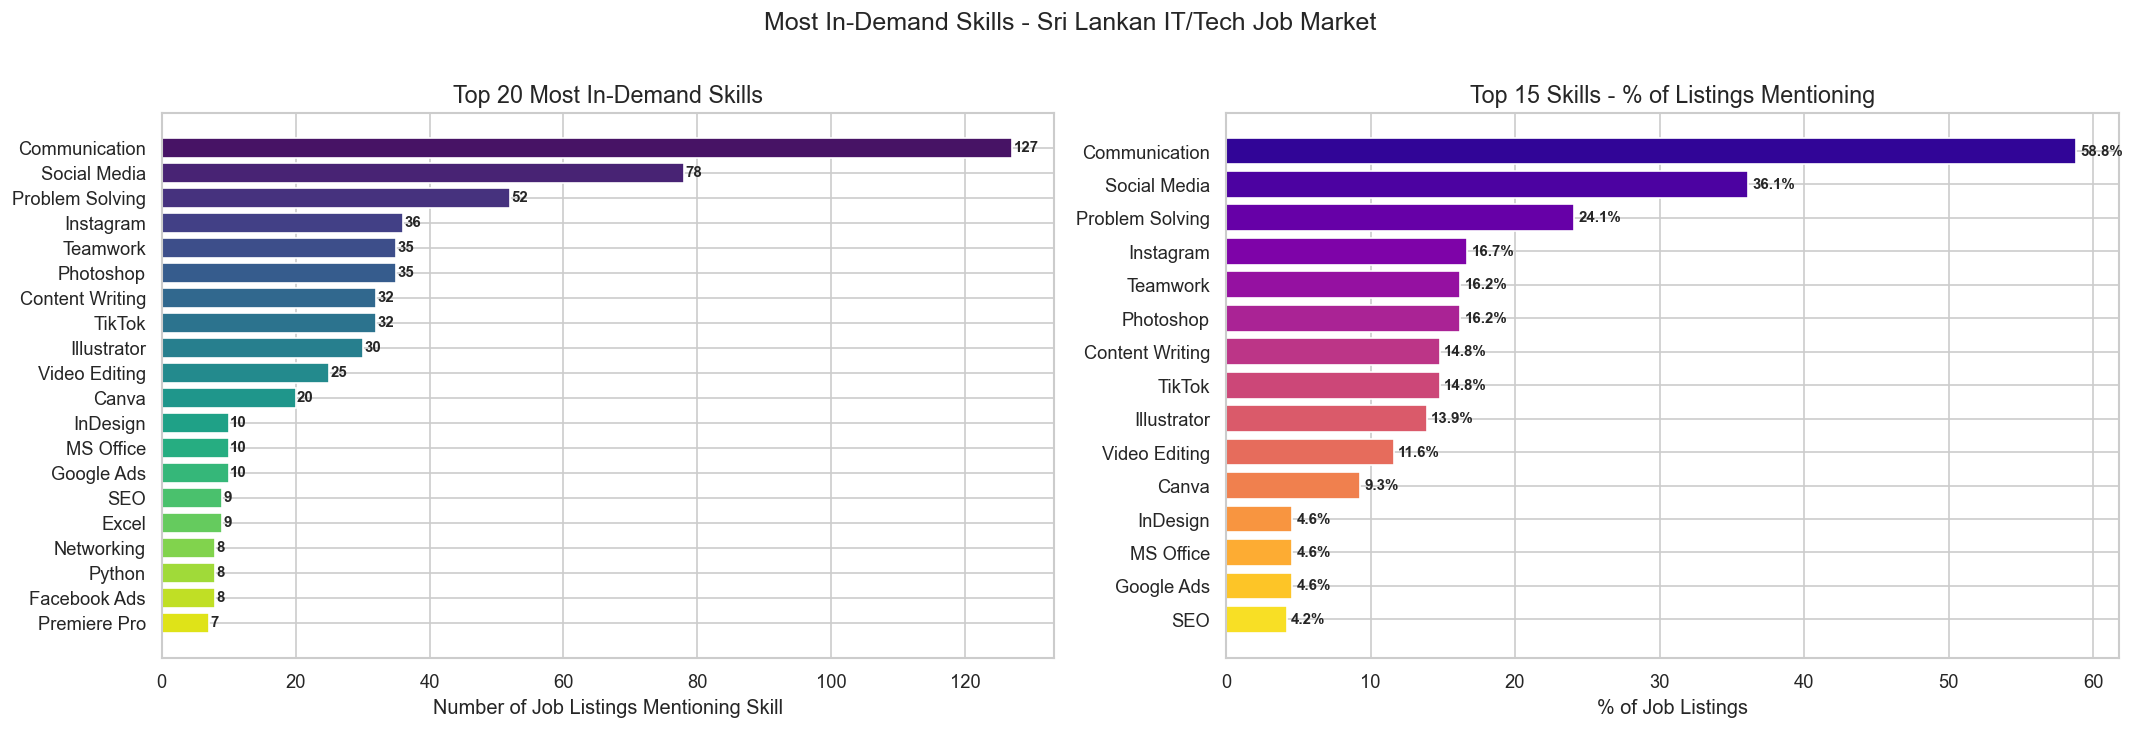

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))


top20 = top_skills.head(20)
colors = sns.color_palette("viridis", len(top20))
bars = axes[0].barh(top20["skill"][::-1], top20["count"][::-1], color=colors[::-1])
axes[0].set_title("Top 20 Most In-Demand Skills")
axes[0].set_xlabel("Number of Job Listings Mentioning Skill")
for bar, val in zip(bars, top20["count"][::-1]):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=9, fontweight="bold")

# % of listings chart (top 15)
top15 = top_skills.head(15)
bars2 = axes[1].barh(top15["skill"][::-1], top15["pct"][::-1],
                     color=sns.color_palette("plasma", len(top15))[::-1])
axes[1].set_title("Top 15 Skills - % of Listings Mentioning")
axes[1].set_xlabel("% of Job Listings")
for bar, val in zip(bars2, top15["pct"][::-1]):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9, fontweight="bold")

plt.suptitle("Most In-Demand Skills - Sri Lankan IT/Tech Job Market", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("data/nlp_plot_01_top_skills_overall.png", bbox_inches="tight")
plt.show()

## 5. Top Skills by Category

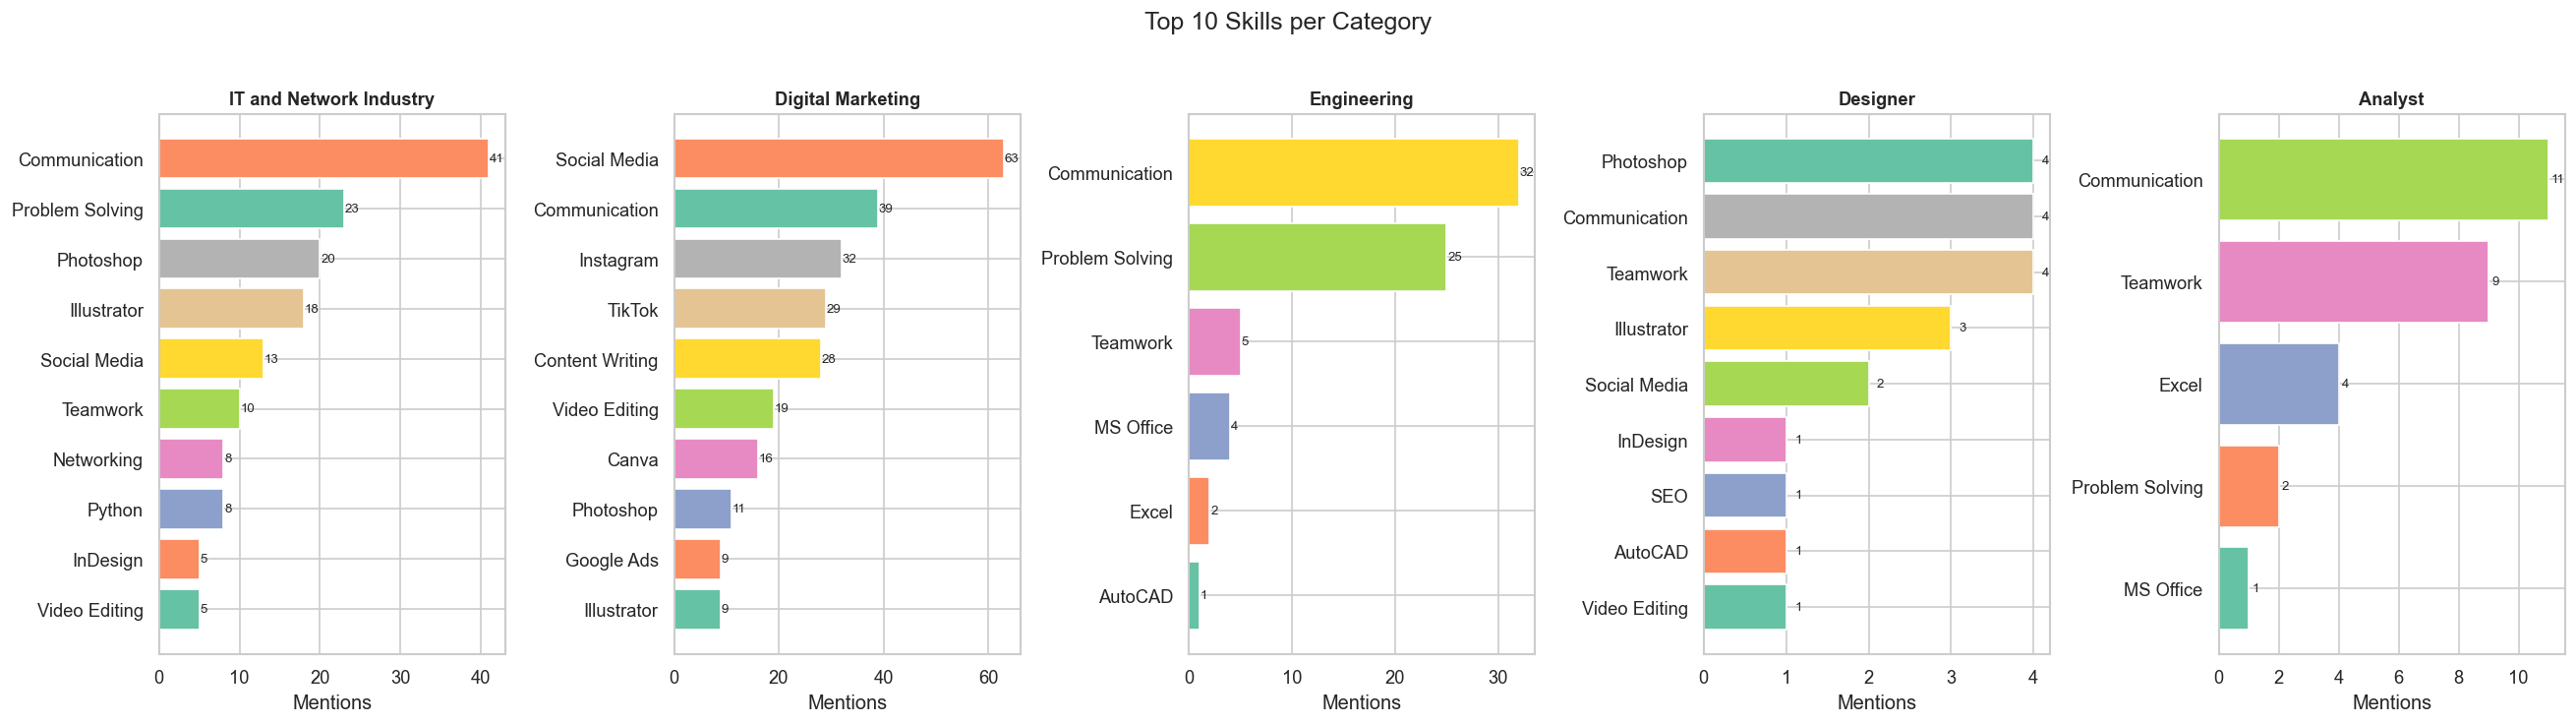

In [32]:
# Build per-category skill frequency
category_skills = {}
for cat in df["category"].unique():
    cat_df = df[df["category"] == cat]
    skills_flat = list(chain.from_iterable(cat_df["skills"]))
    category_skills[cat] = Counter(skills_flat)

# Plot top 10 skills per category
categories = df["category"].unique()
fig, axes = plt.subplots(1, len(categories), figsize=(22, 6))

for ax, cat in zip(axes, categories):
    top = pd.DataFrame(category_skills[cat].most_common(10),
                       columns=["skill", "count"])
    if top.empty:
        ax.set_title(cat)
        continue
    colors = sns.color_palette("Set2", len(top))
    ax.barh(top["skill"][::-1], top["count"][::-1], color=colors)
    ax.set_title(cat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Mentions")
    for i, (_, row) in enumerate(top[::-1].iterrows()):
        ax.text(row["count"] + 0.1, i, str(row["count"]),
                va="center", fontsize=8)

plt.suptitle("Top 10 Skills per Category", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("data/nlp_plot_02_skills_by_category.png", bbox_inches="tight")
plt.show()

## 6. Skills × Category Heatmap

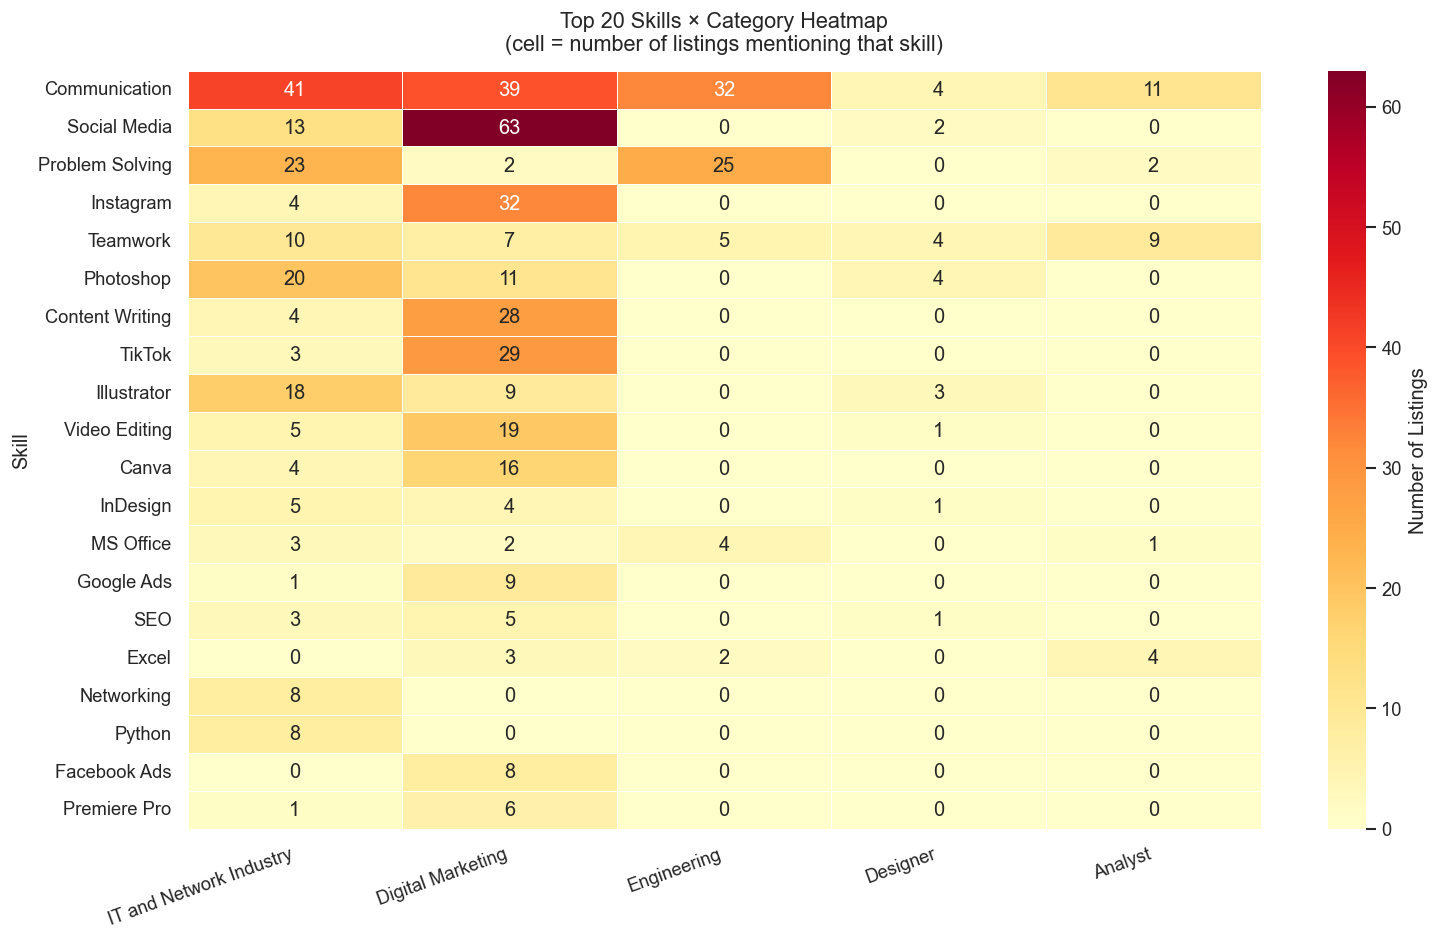

In [33]:
# Get top 20 skills overall
top20_skills = [s for s, _ in skill_counts.most_common(20)]

# Build matrix: rows = skills, cols = categories
heatmap_data = pd.DataFrame(index=top20_skills,
                             columns=df["category"].unique())
for cat in df["category"].unique():
    for skill in top20_skills:
        heatmap_data.loc[skill, cat] = category_skills[cat].get(skill, 0)

heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(13, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Number of Listings"})
plt.title("Top 20 Skills × Category Heatmap\n(cell = number of listings mentioning that skill)",
          fontsize=13, pad=12)
plt.xlabel("")
plt.ylabel("Skill")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("data/nlp_plot_03_skill_heatmap.png", bbox_inches="tight")
plt.show()

## 7. Skill Co-occurrence
*Which skills appear together most often in the same listing?*

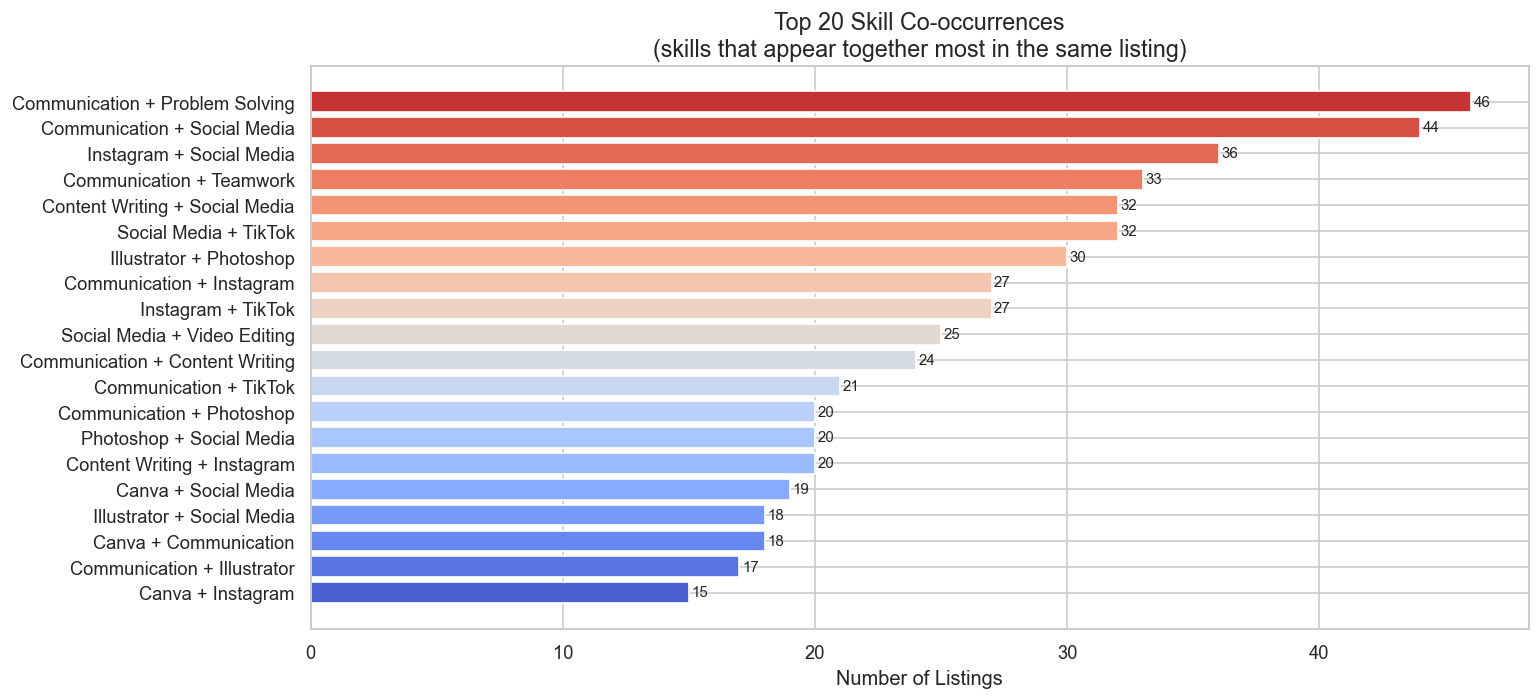

                          label  count
Communication + Problem Solving     46
   Communication + Social Media     44
       Instagram + Social Media     36
       Communication + Teamwork     33
 Content Writing + Social Media     32
          Social Media + TikTok     32
        Illustrator + Photoshop     30
      Communication + Instagram     27
             Instagram + TikTok     27
   Social Media + Video Editing     25
Communication + Content Writing     24
         Communication + TikTok     21
      Communication + Photoshop     20
       Photoshop + Social Media     20
    Content Writing + Instagram     20
           Canva + Social Media     19
     Illustrator + Social Media     18
          Canva + Communication     18
    Communication + Illustrator     17
              Canva + Instagram     15


In [ ]:
from itertools import combinations

# Count pairs
pair_counts = Counter()
for skill_list in df["skills"]:
    for pair in combinations(sorted(set(skill_list)), 2):
        pair_counts[pair] += 1

top_pairs = pd.DataFrame(pair_counts.most_common(20),
                          columns=["pair", "count"])
top_pairs["label"] = top_pairs["pair"].apply(lambda p: f"{p[0]} + {p[1]}")

plt.figure(figsize=(13, 6))
bars = plt.barh(top_pairs["label"][::-1], top_pairs["count"][::-1],
                color=sns.color_palette("coolwarm", len(top_pairs)))
plt.title("Top 20 Skill Co-occurrences\n")
plt.xlabel("Number of Listings")
for bar, val in zip(bars, top_pairs["count"][::-1]):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/nlp_plot_04_skill_cooccurrence.png", bbox_inches="tight")
plt.show()
print(top_pairs[["label", "count"]].to_string(index=False))

## 8. Do More Skills = Higher Salary?

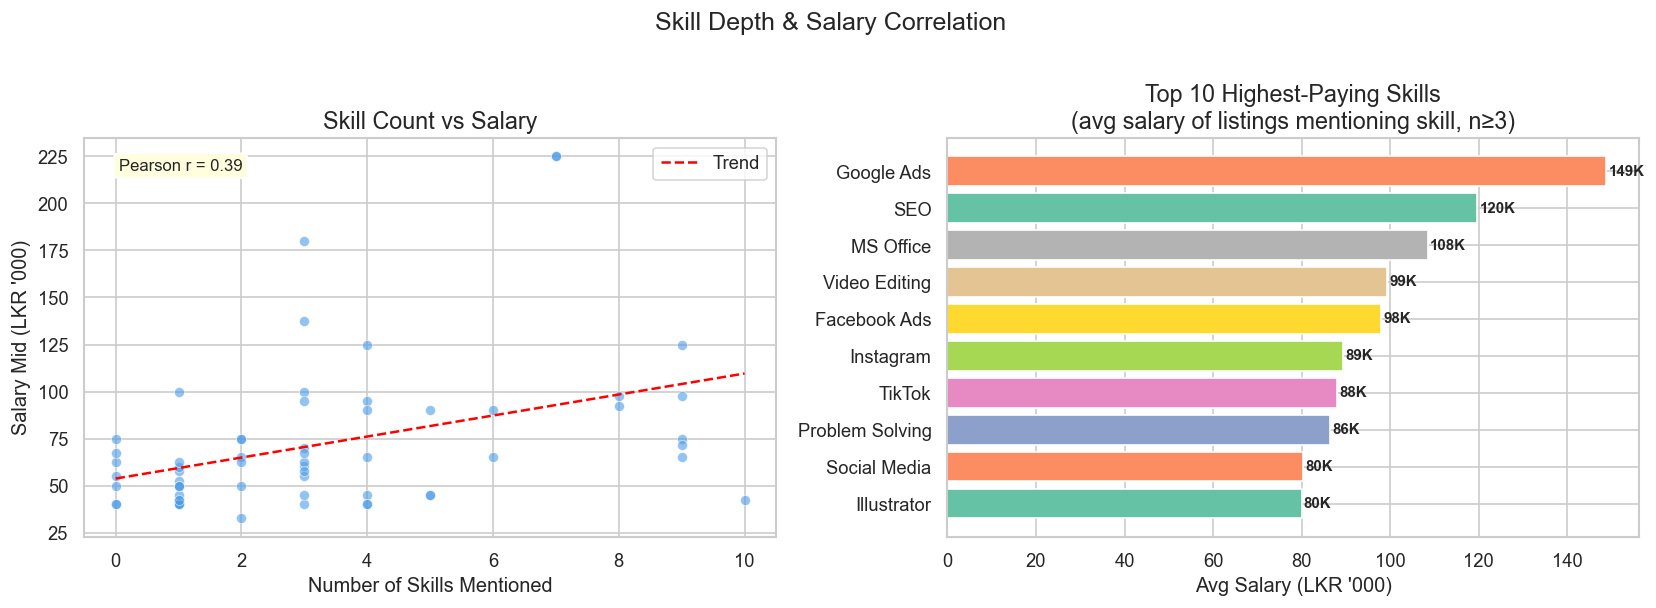

In [ ]:
df_sal = df.dropna(subset=["salary_mid"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: skill count vs salary
axes[0].scatter(df_sal["skill_count"], df_sal["salary_mid"] / 1000,
                alpha=0.6, color="#4C9BE8", edgecolors="white", linewidths=0.5)
# Trend line
z = np.polyfit(df_sal["skill_count"], df_sal["salary_mid"] / 1000, 1)
p = np.poly1d(z)
x_line = np.linspace(df_sal["skill_count"].min(), df_sal["skill_count"].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=1.5, label="Trend")
axes[0].set_title("Skill Count vs Salary")
axes[0].set_xlabel("Number of Skills Mentioned")
axes[0].set_ylabel("Salary Mid (LKR '000)")
axes[0].legend()

corr = df_sal["skill_count"].corr(df_sal["salary_mid"])
axes[0].text(0.05, 0.92, f"Pearson r = {corr:.2f}",
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

# Average salary for top 10 skills 
skill_salary = defaultdict(list)
for _, row in df_sal.iterrows():
    for skill in row["skills"]:
        skill_salary[skill].append(row["salary_mid"])

skill_avg_sal = {k: np.mean(v) for k, v in skill_salary.items() if len(v) >= 3}
sal_df = pd.DataFrame(list(skill_avg_sal.items()),
                      columns=["skill", "avg_salary"]).sort_values("avg_salary", ascending=False).head(10)

bars = axes[1].barh(sal_df["skill"][::-1], sal_df["avg_salary"][::-1] / 1000,
                    color=sns.color_palette("Set2", len(sal_df)))
axes[1].set_title("Top 10 Highest-Paying Skills\n(avg salary of listings mentioning skill, n≥3)")
axes[1].set_xlabel("Avg Salary (LKR '000)")
for bar, val in zip(bars, sal_df["avg_salary"][::-1]):
    axes[1].text(val / 1000 + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val/1000:.0f}K", va="center", fontsize=9, fontweight="bold")

plt.suptitle("Skill Depth & Salary Correlation", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("data/nlp_plot_05_salary_vs_skills.png", bbox_inches="tight")
plt.show()

## 9. Save Enriched Dataset

In [36]:
# Save skills as pipe-separated string for easy CSV storage
df["skills_extracted"] = df["skills"].apply(lambda s: "|".join(s))
output_df = df.drop(columns=["skills"])
output_df.to_csv("data/ikman_jobs_with_skills.csv", index=False, encoding="utf-8")
print(f"Saved enriched dataset: data/ikman_jobs_with_skills.csv")
print(f"Shape: {output_df.shape}")
output_df[["category", "title", "skills_extracted", "skill_count"]].head(10)

Saved enriched dataset: data/ikman_jobs_with_skills.csv
Shape: (216, 12)


,category,title,skills_extracted,skill_count
0,IT and Network Industry,Quality Assurance (QA) Engineer,Communication|Teamwork|Problem Solving,3
1,IT and Network Industry,Hardware Support Engineer,,0
2,IT and Network Industry,Computer Technician,Communication,1
3,IT and Network Industry,Quality Assurance (QA) Engineer,Communication|Teamwork|Problem Solving,3
4,IT and Network Industry,JUNIOR TRAINEE (SOFTWARE DEVELOPMENT & IoT) - ...,Problem Solving,1
5,IT and Network Industry,IT Executive,Networking|Communication,2
6,IT and Network Industry,Graphic Designer - Malabe,Social Media|Photoshop|Illustrator|InDesign|UI...,7
7,IT and Network Industry,Graphic Designer,Social Media|Content Writing|Email Marketing|I...,10
8,IT and Network Industry,IT Hardware Technician (Field Job),Networking|Communication,2
9,IT and Network Industry,ERP System Support Assistant,SQL|Communication|Problem Solving,3


## 10. Key NLP Insights

In [37]:
print("=" * 60)
print("   NLP SKILL EXTRACTION - KEY INSIGHTS")
print("=" * 60)

total_skill_mentions = sum(skill_counts.values())
print(f"\n Total skill mentions extracted : {total_skill_mentions}")
print(f" Unique skills detected         : {len(skill_counts)}")
print(f" Listings with ≥1 skill         : {(df['skill_count']>0).sum()} / {len(df)}")

print(f"\n Top 5 overall skills:")
for skill, count in skill_counts.most_common(5):
    pct = count / len(df) * 100
    print(f"   {skill:<25} {count:>3} listings ({pct:.0f}%)")

print(f"\n Top skill per category:")
for cat in df["category"].unique():
    if category_skills[cat]:
        top_skill, top_count = category_skills[cat].most_common(1)[0]
        n = (df["category"] == cat).sum()
        print(f"   {cat:<28} -> {top_skill} ({top_count}/{n} listings)")

print(f"\n Highest paying skill :")
if sal_df is not None and not sal_df.empty:
    top_pay = sal_df.iloc[0]
    print(f"   {top_pay['skill']} - avg LKR {top_pay['avg_salary']:,.0f}/month")

print("=" * 60)

   NLP SKILL EXTRACTION - KEY INSIGHTS

 Total skill mentions extracted : 629
 Unique skills detected         : 41
 Listings with ≥1 skill         : 185 / 216

 Top 5 overall skills:
   Communication             127 listings (59%)
   Social Media               78 listings (36%)
   Problem Solving            52 listings (24%)
   Instagram                  36 listings (17%)
   Teamwork                   35 listings (16%)

 Top skill per category:
   IT and Network Industry      -> Communication (41/79 listings)
   Digital Marketing            -> Social Media (63/68 listings)
   Engineering                  -> Communication (32/45 listings)
   Designer                     -> Photoshop (4/10 listings)
   Analyst                      -> Communication (11/14 listings)

 Highest paying skill :
   Google Ads - avg LKR 148,800/month


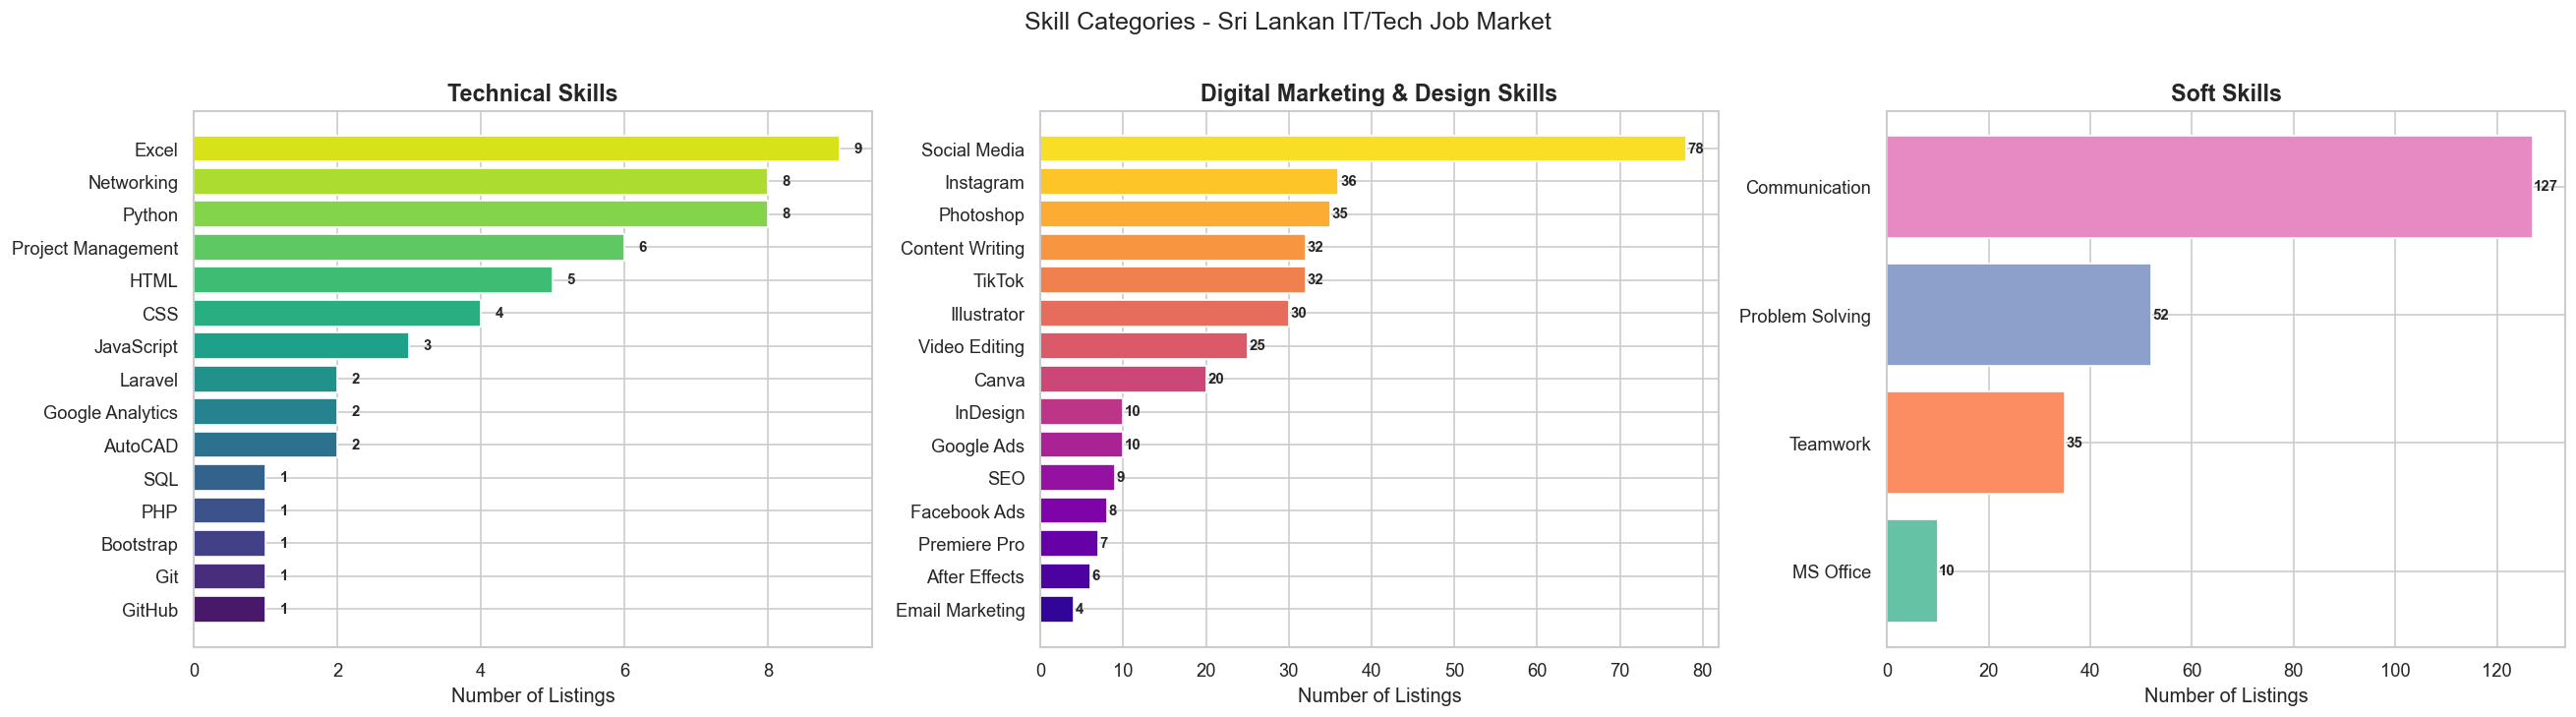

In [41]:
SOFT_SKILLS = {"Communication", "Teamwork", "Problem Solving", "MS Office"}

DIGITAL_MARKETING_DESIGN = {
    "Social Media", "Instagram", "TikTok", "Facebook Ads", "Google Ads",
    "SEO", "SEM", "Email Marketing", "Content Writing", "Canva",
    "Photoshop", "Illustrator", "InDesign", "Video Editing",
    "After Effects", "Premiere Pro", "Figma", "Adobe XD", "UI/UX"
}

tech_counts   = Counter({k: v for k, v in skill_counts.items() if k not in SOFT_SKILLS and k not in DIGITAL_MARKETING_DESIGN})
dm_counts     = Counter({k: v for k, v in skill_counts.items() if k in DIGITAL_MARKETING_DESIGN})
soft_counts   = Counter({k: v for k, v in skill_counts.items() if k in SOFT_SKILLS})

tech_df = pd.DataFrame(tech_counts.most_common(15), columns=["skill", "count"])
dm_df   = pd.DataFrame(dm_counts.most_common(15),   columns=["skill", "count"])
soft_df = pd.DataFrame(soft_counts.most_common(),    columns=["skill", "count"])

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, data, title, palette in zip(
    axes,
    [tech_df, dm_df, soft_df],
    ["Technical Skills", "Digital Marketing & Design Skills", "Soft Skills"],
    ["viridis", "plasma", "Set2"]
):
    bars = ax.barh(data["skill"][::-1], data["count"][::-1],
                   color=sns.color_palette(palette, len(data)))
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Number of Listings")
    for bar, val in zip(bars, data["count"][::-1]):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=9, fontweight="bold")

plt.suptitle("Skill Categories - Sri Lankan IT/Tech Job Market", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("data/nlp_plot_06_skill_categories.png", bbox_inches="tight")
plt.show()